In [7]:
##### Plots SHAP values for final 
# calculates model performance metrics 

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

shap.initjs()  # enables interactive JS plots (force plots) in the notebook

In [8]:
##### SET-UP

# Get the current working directory
cd = Path.cwd().parent.parent 

# import models
capital_rf = joblib.load(f'{cd}/Results/RF_models_final/capital_rf_final/model.joblib')
labor_rf = joblib.load(f'{cd}/Results/RF_models_final/labor_rf_final/model.joblib')

# import training data
capital_data = pd.read_csv(f'{cd}/Data/Clean/Training_data/capital_relative_final_thinned.csv')
labor_data = pd.read_csv(f'{cd}/Data/Clean/Training_data/labor_relative_final_thinned.csv')

In [9]:
##### PREP DATA

# target columns
c_target_col = 'rtv_log_capital_intensity_USD_per_million_tonne'
l_target_col = 'rtv_log_labor_intensity_jobs_per_million_tonne'

# Set feature columns 
capital_cols = ['rtv_log_average_travel_time_port',
       'rtv_log_USD_production_per_million_HA',
       'rtv_log_tonnes_production_per_million_HA',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_cattle_density_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_oilcrops_share_base_100_production_USD',
       'rtv_log_pulses_share_base_100_production_USD',
       'rtv_log_roots_tubers_share_base_100_production_USD',
       'rtv_log_sugar_crops_share_base_100_production_USD',
       'rtv_log_ruminants_share_base_100_production_USD']

labor_cols = ['rtv_log_USD_production_per_million_HA',
       'rtv_log_tonnes_production_per_million_HA',
       'rtv_log_pop_density_people_per_100_km2',
       'rtv_log_livestock_density_LU_per_100_km2',
       'rtv_log_ruminants_share_base_100_production_USD']

# Filter to only feature columns 
capital_features = capital_data[capital_cols]
labor_features = labor_data[labor_cols]

capital_feature_names = capital_features.columns.tolist()
labor_feature_names = labor_features.columns.tolist()

In [10]:
##### CALCULATE SHP VALUES (only needed once - comment out if already run)

explainer = shap.TreeExplainer(capital_rf)
shap_values = explainer(capital_features)
joblib.dump(shap_values, f'{cd}/Results/RF_models_final/capital_rf_final/shap_values.joblib')

explainer = shap.TreeExplainer(labor_rf)
shap_values = explainer(labor_features)
joblib.dump(shap_values, f'{cd}/Results/RF_models_final/labor_rf_final/shap_values.joblib')

['/Users/carinamanitius/Documents/GitHub/AgDownscaling/Results/RF_models_final/labor_rf_final/shap_values.joblib']

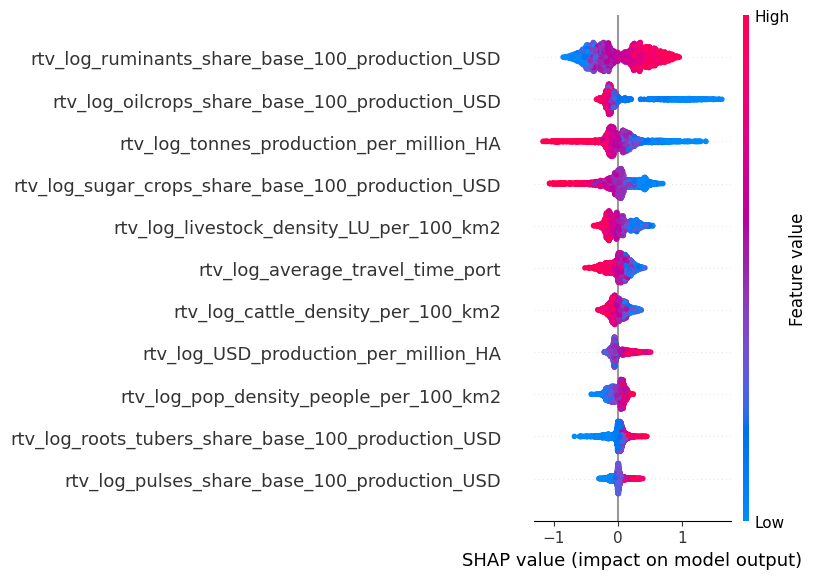

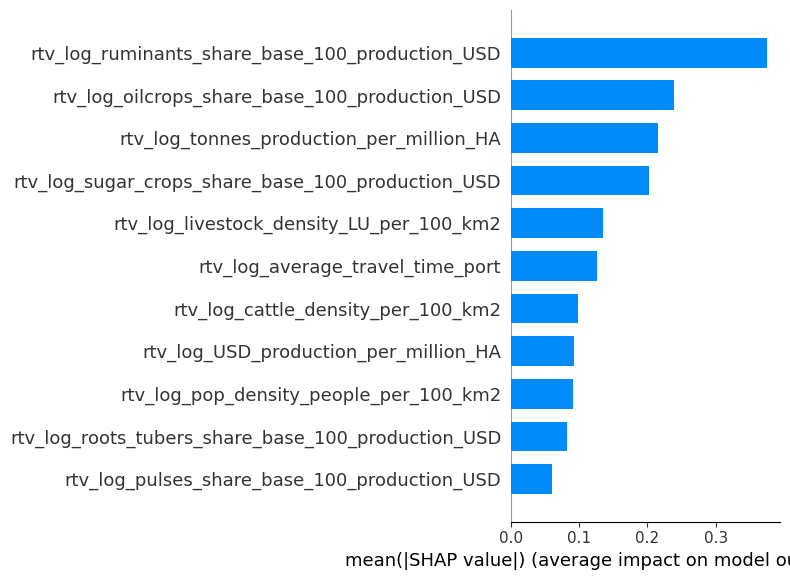

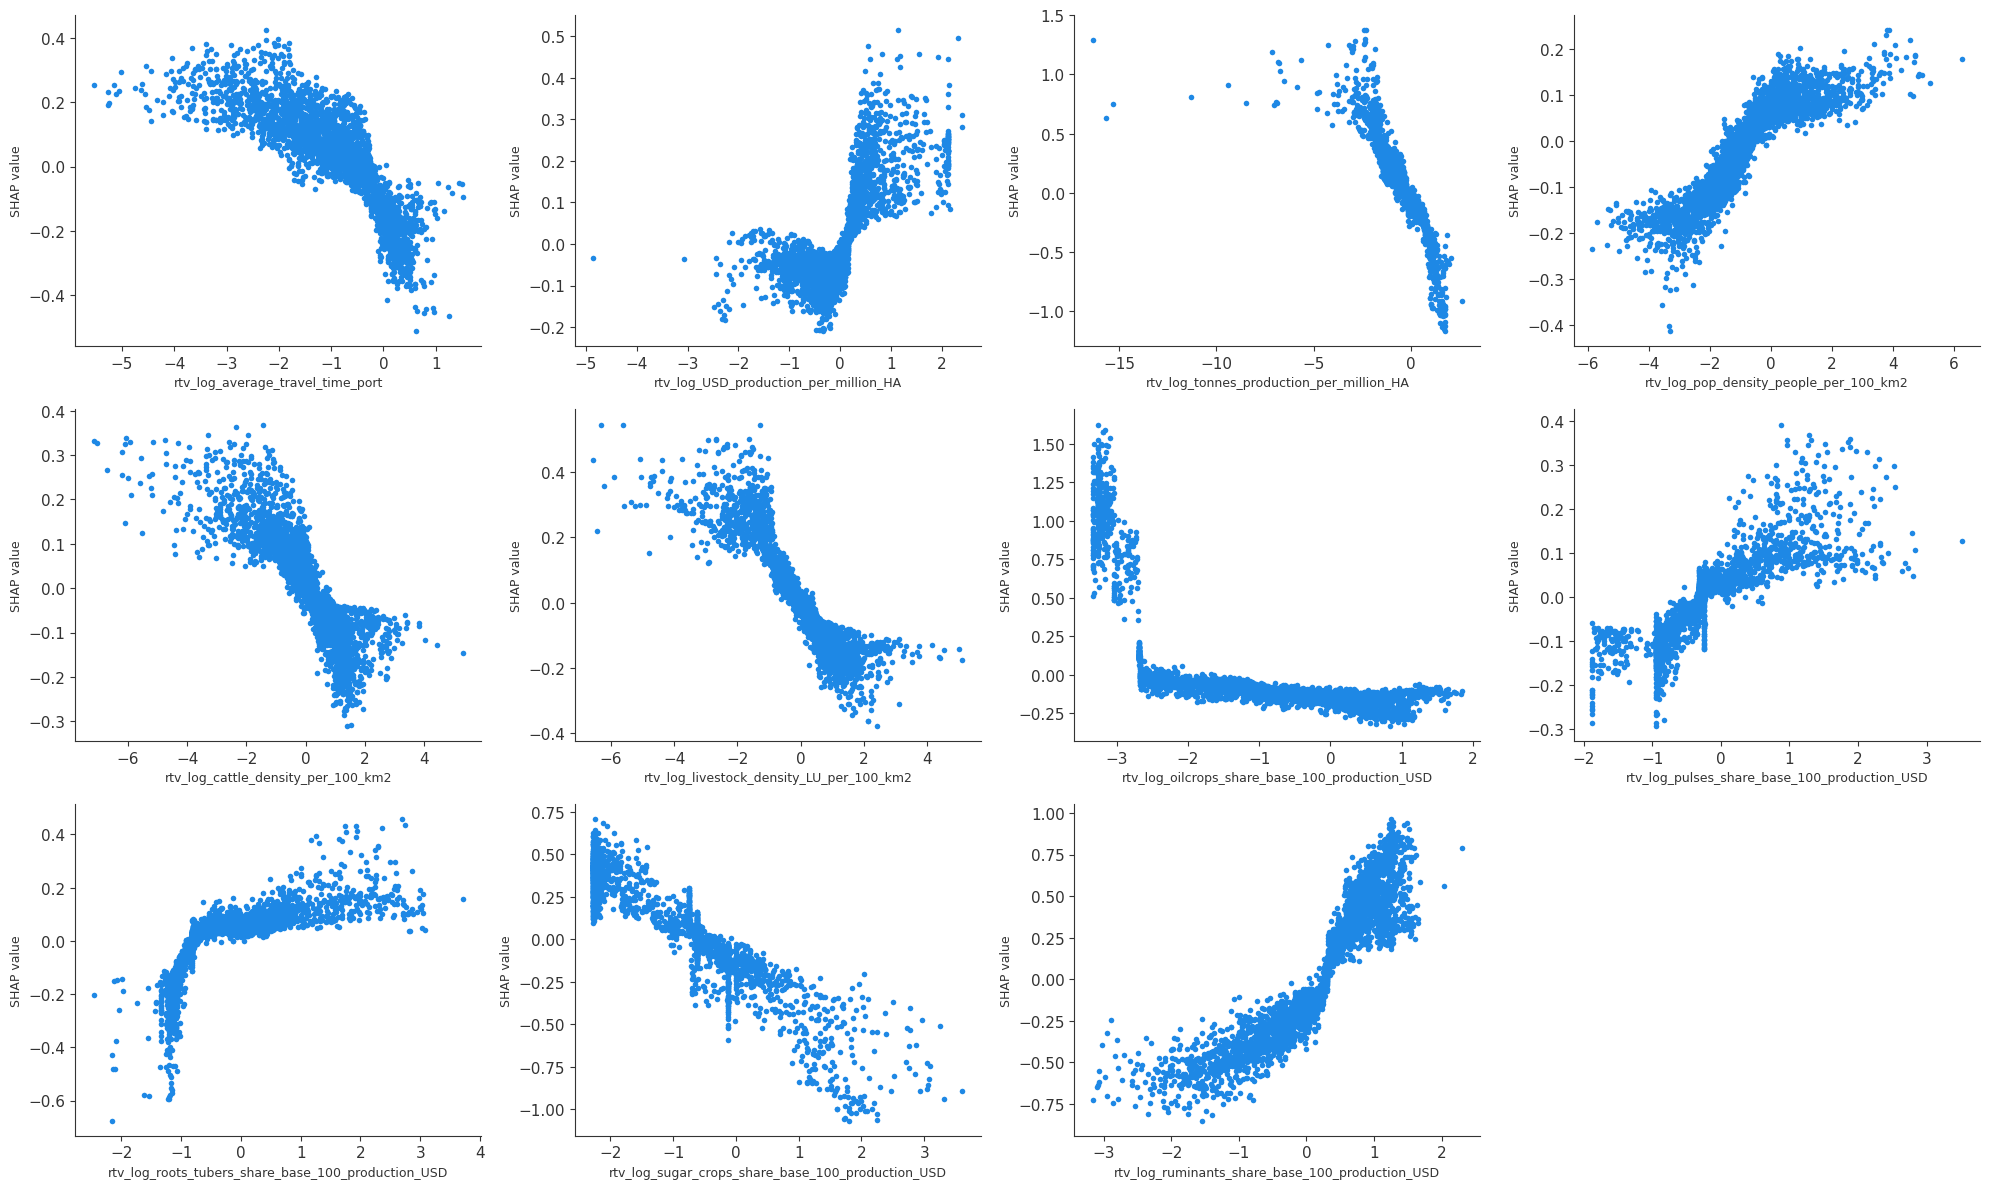

In [11]:
#### Calculate SHAP values for capital model 

# load SHAP values
shap_values = joblib.load(f'{cd}/Results/RF_models_final/capital_rf_final/shap_values.joblib')

## Global feature importance — beeswarm (summary) plot
# Shows the distribution of SHAP values per feature across all samples. Color = feature value (red = high, blue = low).
shap.summary_plot(shap_values, capital_features, show=True)

## Global feature importance — mean |SHAP value| bar plot
shap.summary_plot(shap_values, capital_features, plot_type="bar", show=True)

## Dependence plots for predictors
# Shows each feature's value affects predictions
n_feats = len(capital_feature_names)
n_cols = 4 
n_rows = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  

for i, feat in enumerate(capital_feature_names):
    shap.dependence_plot(feat, shap_values.values, capital_features, ax=axes[i], show=False, interaction_index=None)
    axes[i].set_ylabel("SHAP value", fontsize=9)
    axes[i].set_xlabel(feat, fontsize=9)
    
# hide any unused subplot axes (if n_feats doesn't evenly fill the grid)
for j in range(n_feats, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

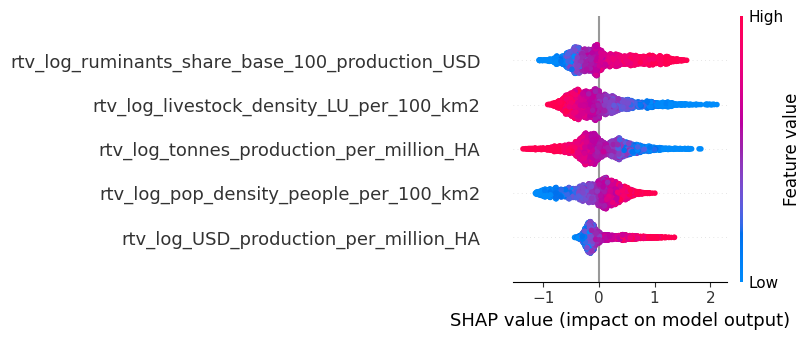

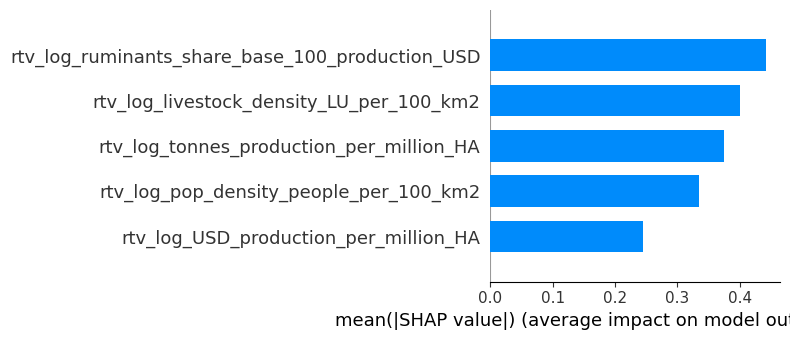

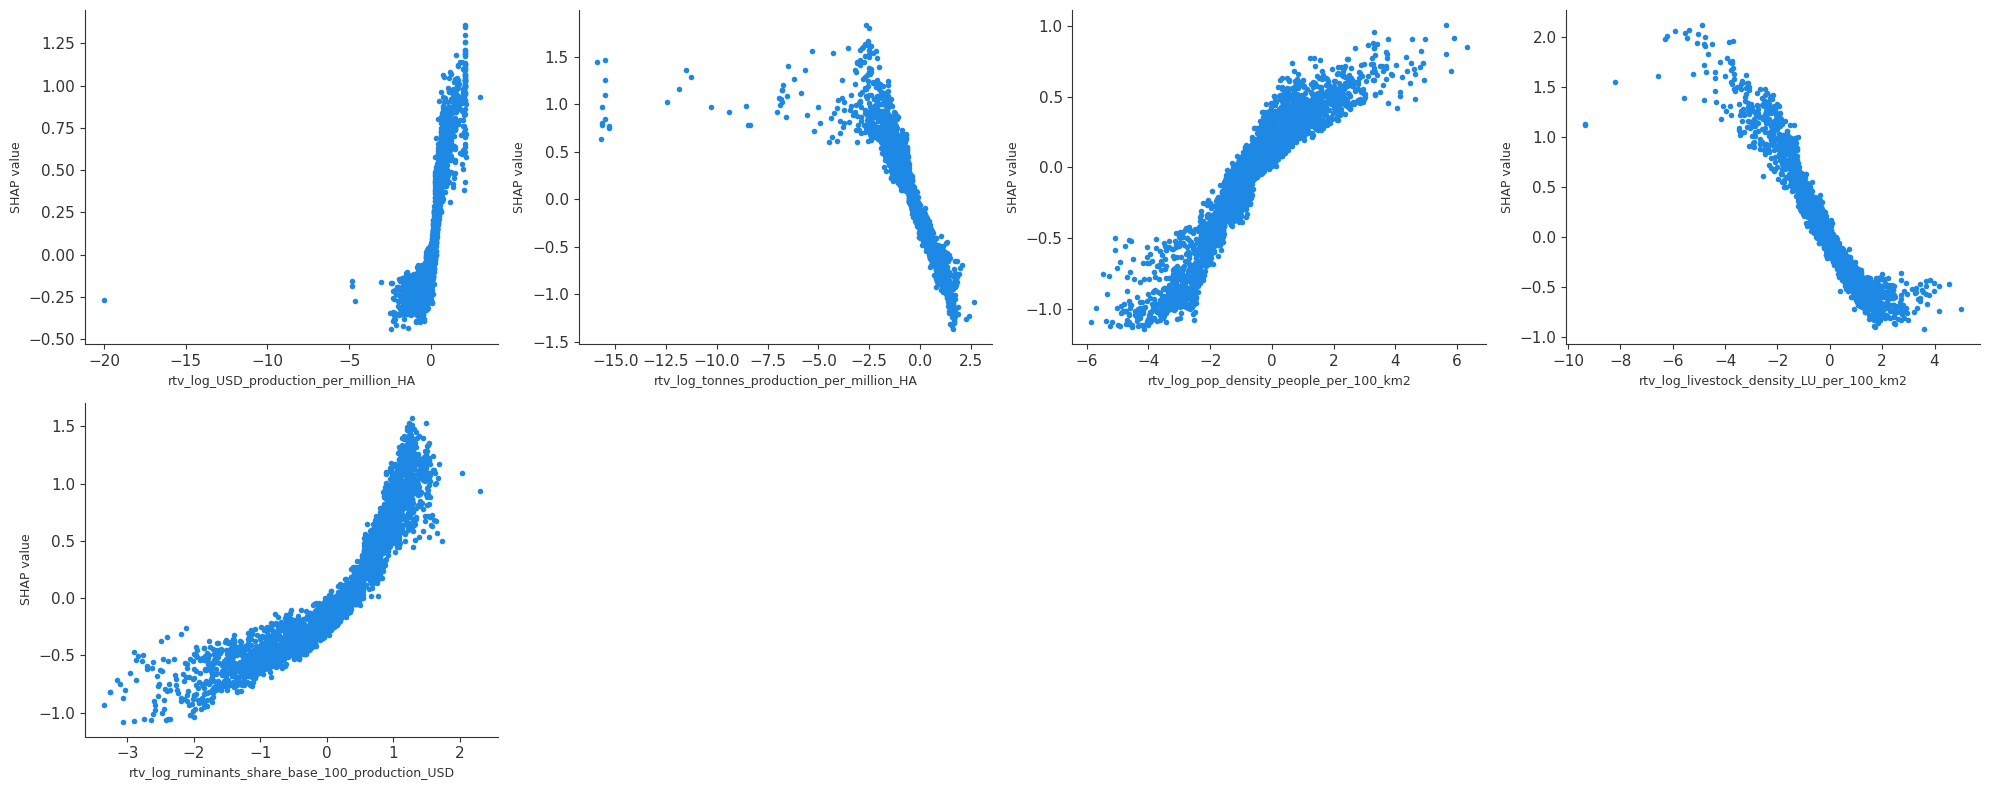

In [12]:
#### Calculate SHAP values for labor model 

# load SHAP values
shap_values = joblib.load(f'{cd}/Results/RF_models_final/labor_rf_final/shap_values.joblib')

## Global feature importance — beeswarm (summary) plot
# Shows the distribution of SHAP values per feature across all samples. Color = feature value (red = high, blue = low).
shap.summary_plot(shap_values, labor_features, show=True)

## Global feature importance — mean |SHAP value| bar plot
shap.summary_plot(shap_values, labor_features, plot_type="bar", show=True)

## Dependence plots for predictors
# Shows each feature's value affects predictions
n_feats = len(labor_feature_names)
n_cols = 4 
n_rows = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  

for i, feat in enumerate(labor_feature_names):
    shap.dependence_plot(feat, shap_values.values, labor_features, ax=axes[i], show=False, interaction_index=None)
    axes[i].set_ylabel("SHAP value", fontsize=9)
    axes[i].set_xlabel(feat, fontsize=9)
    
# hide any unused subplot axes (if n_feats doesn't evenly fill the grid)
for j in range(n_feats, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()